# Day 4 - Week 3

In [3]:
from IPython.display import Image, display
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('../../week1/day4/train.csv')
df.drop(['PassengerId','Name','Ticket','Cabin'],axis = 1,inplace = True)
df =pd.get_dummies(df)
df['Age']=df['Age'].fillna(df['Age'].mean())


target = 'Survived'
X = df.drop(target,axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## 1. Decision Tree

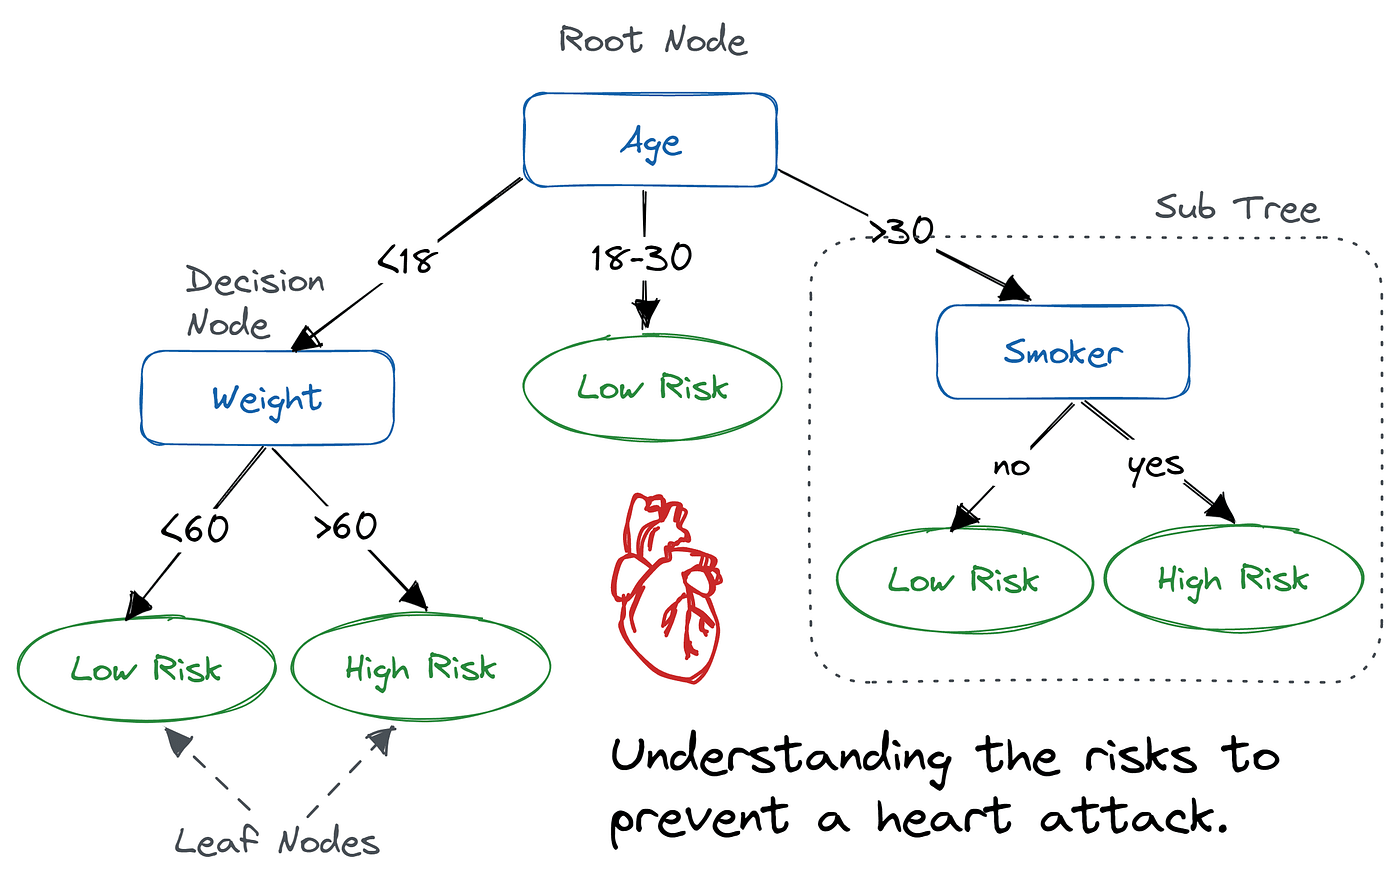

In [5]:
display(Image(filename='assets/decision_tree.png'))

#### Decision Tree
1. Works like a flowchart.
2. Makes decisions using a series of questions.
3. Can be used for classification and regression.
4. it consist of:
   
   A. **Root node**: The first question or condition 
   
   B. **Internal node**: Another question or condition used to split data  
   
   C. **Branch**: The answer of the question
   
   D. **Leaf node**: Final Decision
5. Usually no need for a scalling to data 
6. The worse thing with the decision tree is the **Overfitting**.

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred = dt.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.7877094972067039


## 2. Random Forest

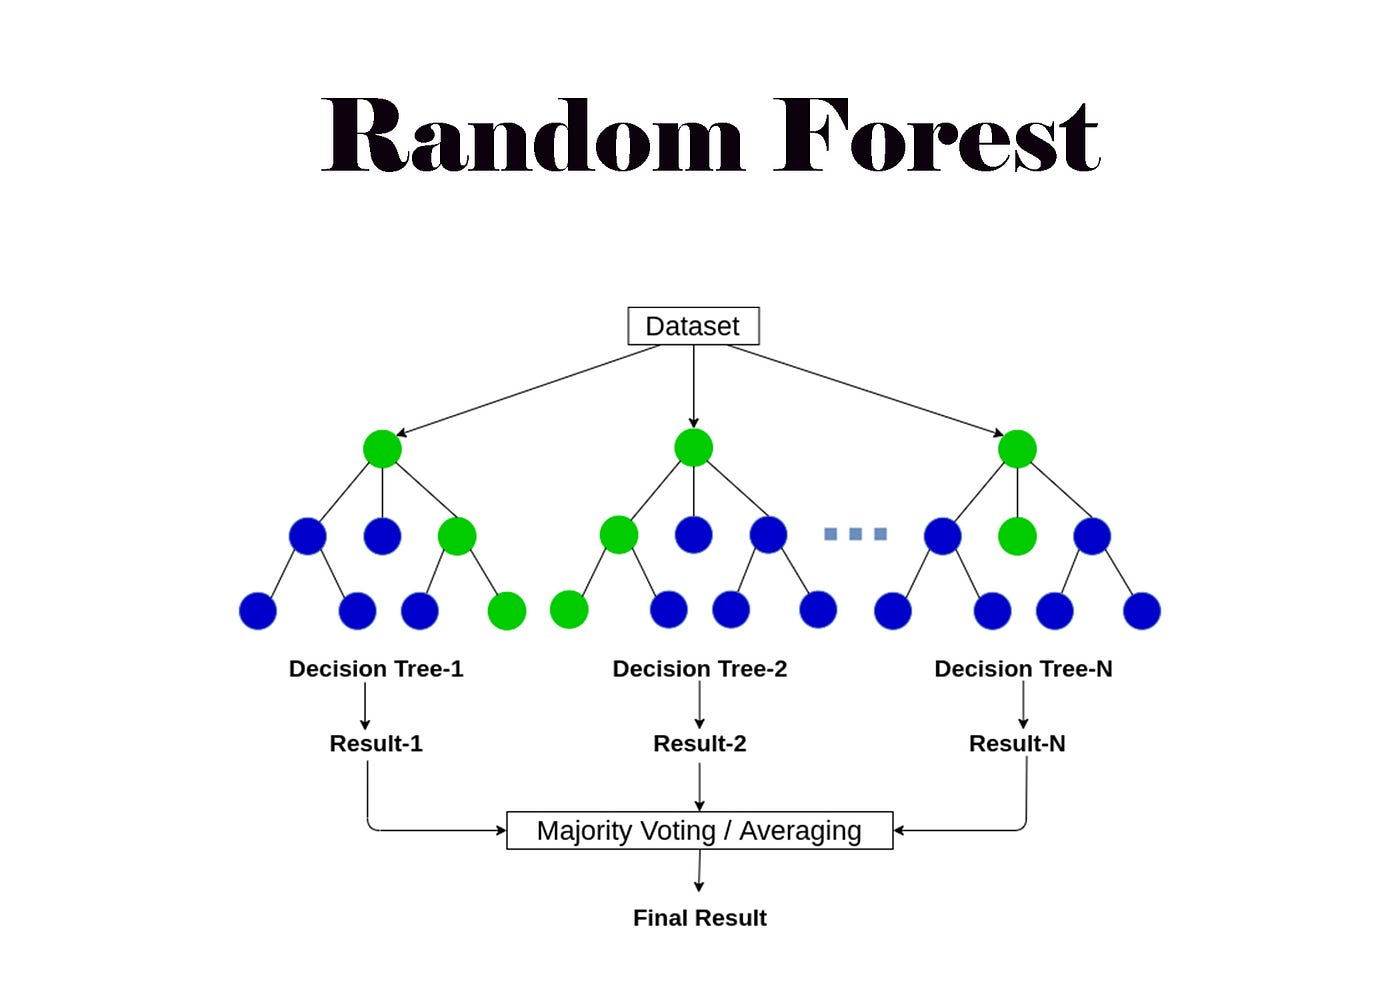

In [9]:
display(Image(filename='assets/random_forest.jpg'))

#### Random Forest
1. A group of many decision trees.
2. Each tree gives a prediction, then the final result is based on voting.
3. Usually more accurate than one decision tree.
4. As we say the **Decision Tree** has a disadvantage of **Overfitting**.
   **Random Forest** Helps reduce **Overfitting**.
5. It has disadvantages such as: slower than one tree, it requeirs more memory, and its more complex 

In [16]:
from sklearn.ensemble import RandomForestClassifier

rm = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rm.fit(X_train, y_train)
pred1 = rm.predict(X_test)
print(rm.feature_importances_)   # which features mattered most
accuracy = accuracy_score(y_test, pred1)
print("Accuracy:", accuracy)

[0.08548418 0.24513489 0.04927086 0.03631201 0.26099867 0.12163101
 0.16304403 0.01472959 0.00748643 0.01590833]
Accuracy: 0.8156424581005587


## 3. SVM

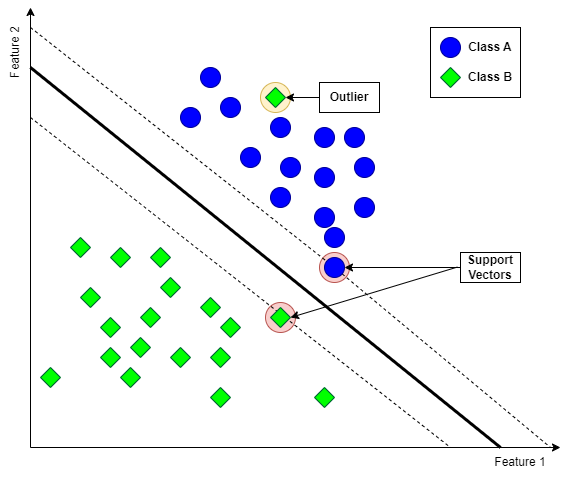

In [11]:
display(Image(filename='assets/svm.webp'))

#### SVM
1. Finds the best boundary between different classes.
2. Tries to keep the largest possible distance between the classes.
3. Works well with small and medium datasets.
4. Usually requires feature scaling.
5. Important settings are:

A. C: it controls the trade-off between,

 **Large C value** let the model tries to classify all training samples correctly, which is highr risk of **Overfitting**

 **Small C value** let the model has more errors, but it leads to better generalization 

B. gamma: It determines how much each training sample has impact on the decision boundary.

 **Large gamma value** Complex decision boundary, high risk of overfitting.

 **Small gamma value** Smooth decision boundary, better generalization.
 
6. it has disadvantages such as: it may be too slow with larger datasets.


In [13]:
from sklearn.svm import SVC

svm = SVC(
    kernel="linear",
    C=1.0
)

svm.fit(X_train, y_train)
pred2 = svm.predict(X_test)
accuracy = accuracy_score(y_test, pred2)
print("Accuracy:", accuracy)

Accuracy: 0.7821229050279329


## K-NN

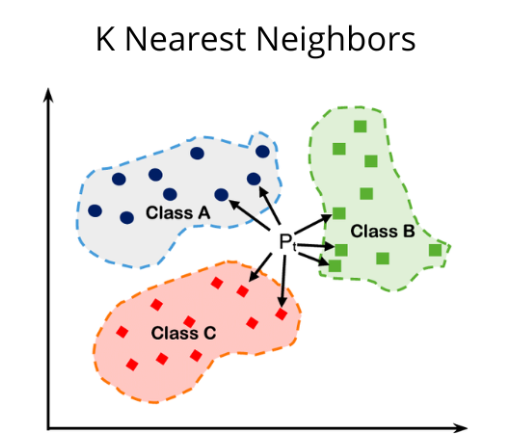

In [14]:
display(Image(filename='assets/k-nn.png'))

#### K-NN
1. Classifies a new point based on its nearest neighbors.
2. The value of k represents the number of neighbors used.
3. Requires feature scaling because **it depends on distance**.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)
pred3 = knn.predict(X_test)
accuracy = accuracy_score(y_test, pred3)
print("Accuracy:", accuracy)

Accuracy: 0.7150837988826816


## Comparing Models

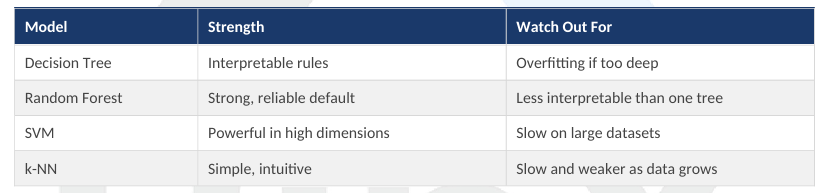

In [17]:
display(Image(filename='assets/cm.png'))